<br>
<center><h1>EDA</h1></center>
<br>

Table of Contents

1. [Load Packages](#setup)
- Load Pandas, Numpy, Matplotlib, and Seaborn packages

2. [Inspect Data](#inspect)
- Inspect data, descriptive statistics, see shape, evaluate data type, and non-null count

3. [Impute Missing Values](#impute)
- Impute bedrooms, bathrooms, sqft_living, and sqft_lot missing values

4. [Outlier Removal](#outlier)
- Identify extreme outliers (3.0 * IQR) from key columns and remove them
- Save the pre-outlier removal data for comparison in the modeling stage

5. [Feature Construction](#features)
- Construct features
- Drop unnecessary columns including ID, Date, Year Built, Year Renovated, Zipcode, Latitude, and Longitude

6. [Data Export](#export)
- Export the data to the visualization and modeling folders for further use

7. [Main Takeaways](#takeaways)

# Load Packages
<a id='setup'></a>

In [282]:
# Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inspect Data
<a id='inspect'></a>

In [283]:
# Import the dataset using pandas read_csv
df = pd.read_csv("house_sales.csv")

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Ensure head displays all columns
pd.set_option('display.max_columns', None)

# Display the top 5 rows
df_head = df.drop(['date', 'id'], axis=1)
df_head.head().round(2).T

,0,1,2,3,4
price,"221,900.00","538,000.00","180,000.00","604,000.00","510,000.00"
bedrooms,3.00,3.00,2.00,4.00,3.00
bathrooms,1.00,2.25,1.00,3.00,2.00
sqft_living,"1,180.00","2,570.00",770.00,"1,960.00","1,680.00"
sqft_lot,"5,650.00","7,242.00","10,000.00","5,000.00","8,080.00"
floors,1.00,2.00,1.00,1.00,1.00
waterfront,0.00,0.00,0.00,0.00,0.00
view,0.00,0.00,0.00,0.00,0.00
condition,3.00,3.00,3.00,5.00,3.00
grade,7.00,7.00,6.00,7.00,8.00


In [284]:
# Calculate descriptive statistics including Skewness
stats = df.describe().round(2).drop(['date', 'id'], axis=1).T
stats['skew'] = df.select_dtypes(include=[np.number]).skew()

print("--- Descriptive Statistics with Skewness ---")
display(stats[['mean', '50%', 'std', 'min', 'max', 'skew']])

--- Descriptive Statistics with Skewness ---


,mean,50%,std,min,max,skew
price,"540,088.14","450,000.00","367,127.20","75,000.00","7,700,000.00",4.02
bedrooms,3.37,3.00,0.93,0.00,33.00,2.02
bathrooms,2.11,2.25,0.77,0.00,8.00,0.50
sqft_living,"2,081.07","1,920.00",915.04,290.00,"12,050.00",1.39
sqft_lot,"15,179.82","7,620.00","41,486.17",520.00,"1,651,359.00",12.88
floors,1.49,1.50,0.54,1.00,3.50,0.62
waterfront,0.01,0.00,0.09,0.00,1.00,11.39
view,0.23,0.00,0.77,0.00,4.00,3.40
condition,3.41,3.00,0.65,1.00,5.00,1.03
grade,7.66,7.00,1.18,1.00,13.00,0.77


In [285]:
# Display the shape of the dataframe
shape_df = pd.DataFrame(
    df.shape,
    index=["Rows", "Columns"],
    columns=["Count"],
)
display(shape_df)

# Display count by data type
dtype_df = df.dtypes.value_counts().to_frame(name="Number of Columns")
dtype_df.index.name = "Data Type"
display(dtype_df.reset_index())

,Count
Rows,21613
Columns,21


,Data Type,Number of Columns
0,int64,12
1,float64,8
2,datetime64[ns],1


In [286]:
# Display column number, column name, non-null count, and data type
info_df = pd.DataFrame(
    {
        "Column": df.columns,
        "Non-Null Count": df.notnull().sum().values,
        "Dtype": df.dtypes.values,
    }
)

display(info_df.reset_index(drop=True))

,Column,Non-Null Count,Dtype
0,id,21613,int64
1,date,21613,datetime64[ns]
2,price,21613,float64
3,bedrooms,20479,float64
4,bathrooms,20545,float64
5,sqft_living,20503,float64
6,sqft_lot,20569,float64
7,floors,21613,float64
8,waterfront,21613,int64
9,view,21613,int64


# Impute Missing Values
<a id='impute'></a>

Missing data was handled using variable-specific imputation strategies to preserve as many observations as possible while maintaining realistic data distributions.

1. Total living area (`sqft_living`) was imputed by summing `sqft_above` and `sqft_basement`, which contained no missing values.
2. Total lot size (`sqft_lot`) was imputed using the median within each `zipcode`.
3. An extreme outlier (33 bedrooms) was replaced with the median value for its corresponding `grade`.
4. Records with zero bedrooms or bathrooms were treated as missing and set to null prior to imputation.
5. `Bedrooms` were imputed using a living space–to–bedroom ratio by `grade`, with a fallback to a global ratio. Values were rounded to the nearest whole number.
6. `Bathrooms` were imputed using a living space–to–bathroom ratio by `grade`, with a fallback to a global ratio. Values were rounded to the nearest quarter unit.

In [287]:
# Display dimensions with NA values
null_counts = df.isna().sum()
null_counts.index.name = "Column"
null_df = pd.DataFrame(null_counts[null_counts > 0], columns=["Count"])
display(null_df.reset_index())

,Column,Count
0,bedrooms,1134
1,bathrooms,1068
2,sqft_living,1110
3,sqft_lot,1044


In [288]:
# Impute sqft_living for all values by adding sqft_above and sqft_basement
df["sqft_living"] = df["sqft_above"] + df["sqft_basement"]

# Check NA values
assert (
    df["sqft_living"] - (df["sqft_above"] + df["sqft_basement"])
).sum() == 0
print("sqft_living fully reconstructed and validated.")

sqft_living fully reconstructed and validated.


In [289]:
# Impute missing values from sqft_lot by zip code median
zip_lot_medians = df.groupby('zipcode')['sqft_lot'].transform('median')
df['sqft_lot'] = df['sqft_lot'].fillna(zip_lot_medians)

In [290]:
# Identify the outlier (33 bedrooms)
# Replace with the median for its grade
outlier_grade = df.loc[df['bedrooms'] == 33, 'grade'].iloc[0]
grade_median = df[df['grade'] == outlier_grade]['bedrooms'].median()
df.loc[df['bedrooms'] == 33, 'bedrooms'] = grade_median

# Turn bed and bath zeroes into nulls for imputation
df.loc[df['bedrooms'] == 0, 'bedrooms'] = np.nan
df.loc[df['bathrooms'] == 0, 'bathrooms'] = np.nan

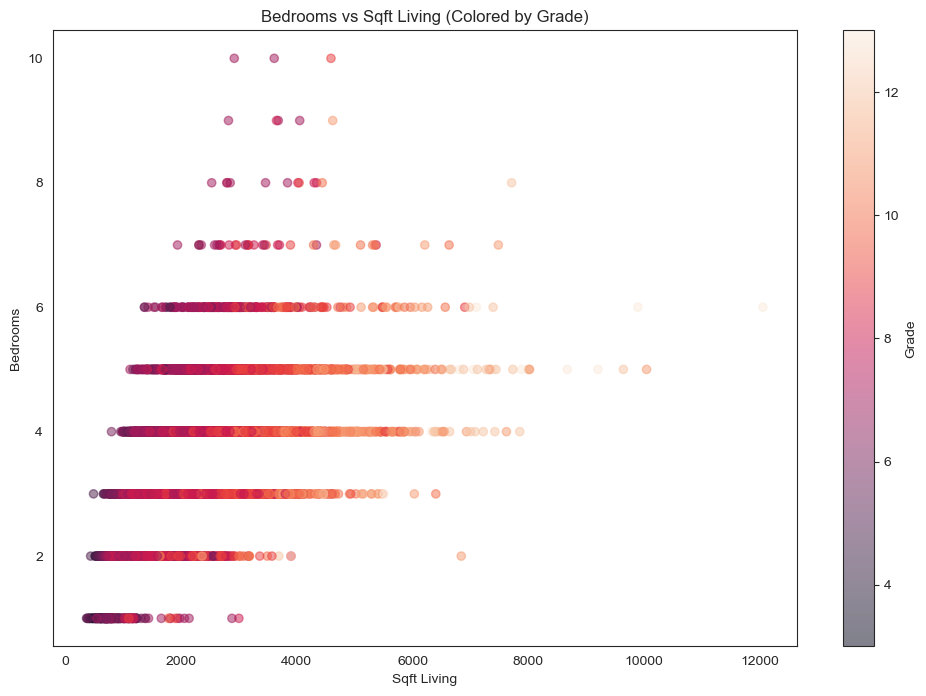

In [291]:
# Plot relationship between bedrooms, sqft_living, and grade
x = df['sqft_living']
y = df['bedrooms']
color = df['grade']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c=color, alpha=0.5)
plt.colorbar(label='Grade')
plt.xlabel('Sqft Living')
plt.ylabel('Bedrooms')
plt.title('Bedrooms vs Sqft Living (Colored by Grade)')
plt.show()

In [292]:
# Impute bedroom values from median sqft_living per bedrooms and grade

# Primary strategy - group by grade, median sqft_per_bed
df["sqft_per_bed"] = df["sqft_living"] / df["bedrooms"]
grade_bed_median = df.groupby("grade")["sqft_per_bed"].transform("median")

# Backup strategy - global bed median if primary does not work
# (one grade 1 example)
global_bed_median = (df["sqft_living"] / df["bedrooms"]).median()
imputed_beds = df["sqft_living"] / grade_bed_median.fillna(
    global_bed_median)
df["bedrooms"] = df["bedrooms"].fillna(imputed_beds).round().astype(int)

df = df.drop("sqft_per_bed", axis=1)

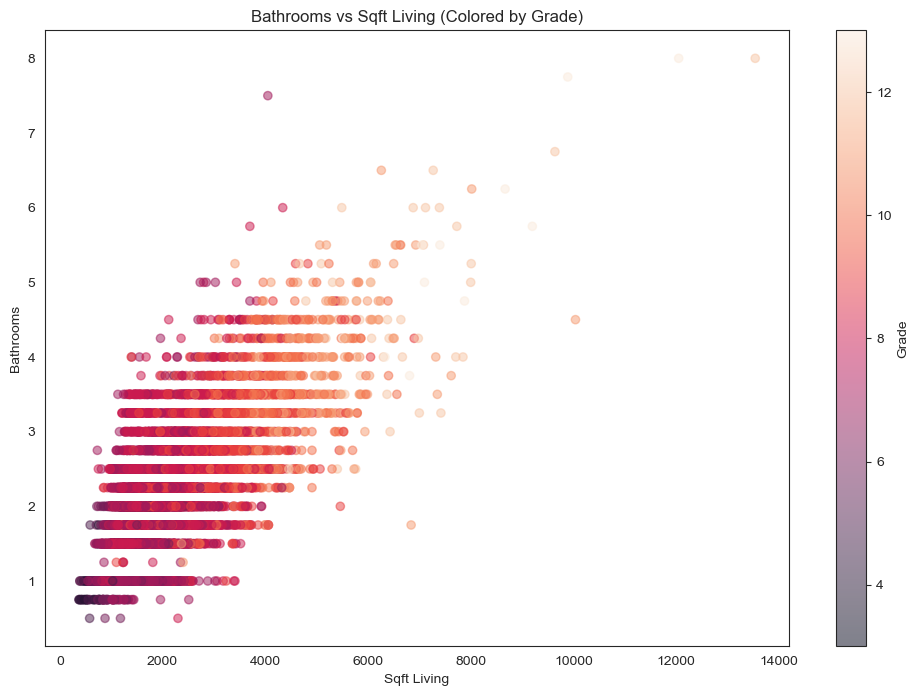

In [293]:
# Plot relationship between bathrooms, sqft_living, and grade
x = df["sqft_living"]
y = df["bathrooms"]
color = df["grade"]

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c=color, alpha=0.5)
plt.colorbar(label="Grade")
plt.xlabel("Sqft Living")
plt.ylabel("Bathrooms")
plt.title("Bathrooms vs Sqft Living (Colored by Grade)")
plt.show()

In [294]:
# Impute bathroom values from median sqft_living per bathrooms and grade

# Primary strategy - group by grade, median sqft_per_bath
df["sqft_per_bath"] = df["sqft_living"] / df["bathrooms"]
grade_bath_median = df.groupby(
    "grade")["sqft_per_bath"].transform("median")

# Backup strategy - global bath median if primary does not work
# (one grade 1 example)
global_bath_median = (df["sqft_living"] / df["bathrooms"]).median()
imputed_baths = df["sqft_living"] / grade_bath_median.fillna(
    global_bath_median
)
df["bathrooms"] = df["bathrooms"].fillna(imputed_baths)

df = df.drop("sqft_per_bath", axis=1)

# Round bathrooms to a quarter point to match all data
df["bathrooms"] = (df["bathrooms"] * 4).round() / 4

# Check NA values
missing_columns = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot"]
missing_summary = df[missing_columns].isna().sum().to_frame(
    name="Missing Values"
)

missing_summary.index.name = "Column"
display(missing_summary.reset_index())

,Column,Missing Values
0,bedrooms,0
1,bathrooms,0
2,sqft_living,0
3,sqft_lot,0


In [295]:
# Check summary metrics after imputing missing values
pd.set_option("display.float_format", "{:,.2f}".format)
stats = df.describe().round(2).drop(['date', 'id'], axis=1).T
stats['skew'] = df.select_dtypes(include=[np.number]).skew()
display(stats[['mean', '50%', 'std', 'min', 'max', 'skew']])

,mean,50%,std,min,max,skew
Column,,,,,,
price,"540,088.14","450,000.00","367,127.20","75,000.00","7,700,000.00",4.02
bedrooms,3.38,3.00,0.91,1.00,11.00,0.54
bathrooms,2.11,2.25,0.77,0.25,8.00,0.52
sqft_living,"2,079.90","1,910.00",918.44,290.00,"13,540.00",1.47
sqft_lot,"14,853.75","7,663.00","40,511.67",520.00,"1,651,359.00",13.19
floors,1.49,1.50,0.54,1.00,3.50,0.62
waterfront,0.01,0.00,0.09,0.00,1.00,11.39
view,0.23,0.00,0.77,0.00,4.00,3.40
condition,3.41,3.00,0.65,1.00,5.00,1.03


In [296]:
# Copy the df for comparison with outliers
# Adding feature engineered columns in a later step.
df_pre_outlier_removal = df.copy()

# Outlier Removal
<a id='outlier'></a>

- Outliers were removed only if they were extreme, defined as values lying beyond 3.0 × IQR from Q1 or Q3.
- A 3.0 × IQR threshold was used instead of the traditional 1.5 × IQR to remove only extreme outliers while preserving legitimate observations in a naturally skewed housing dataset.
- Outlier removal was applied selectively to specific variables:
    - Variables such as `bathrooms`, `view`, `waterfront`, `yr_renovated`, `lat` and `long` were excluded, as extreme values in these fields represent valid property characteristics rather than data errors.
    - Similarly, `sqft_living15` and `sqft_lot15` were excluded, as they reflect neighboring property attributes rather than the subject property.
    - Outlier removal was applied to key structural and price-related variables, including `price`, `bedrooms`, `sqft_living`, `grade`, `sqft_above`, and `sqft_basement`.
    - Highly skewed variables such as `price` and `sqft_lot` were also log-transformed, which helps mitigate the influence of outliers while preserving more observations and improving distributional properties for regression.

In [297]:
# Define the columns you want to filter
cols_to_filter = [
    "price",
    "bedrooms",
    "sqft_living",
    "grade",
    "sqft_above",
    "sqft_basement",
]

# Identify outliers using the 3.0 * IQR rule
# We calculate bounds based on the original dataframe (df)
q1 = df[cols_to_filter].quantile(0.25)
q3 = df[cols_to_filter].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3.0 * iqr
upper_bound = q3 + 3.0 * iqr

# Create a boolean mask where True means it is an extreme outlier
outlier_mask = (df[cols_to_filter] < lower_bound) | (
    df[cols_to_filter] > upper_bound
)

# Identify indices where any of the specified columns have an outlier
to_drop_indices = outlier_mask.any(axis=1)
df_no_outliers = df[~to_drop_indices].copy()

# Print the impact of dropping rows
rows_dropped = len(df) - len(df_no_outliers)
percentage_dropped = round((rows_dropped / len(df)) * 100, 2)

print(
    f"The number of rows dropped since the original dataframe: "
    f"{rows_dropped}"
)
print(
    f"The percentage of rows dropped since the original dataframe: "
    f"{percentage_dropped}%"
)

# Final verification: Check for remaining outliers in the new dataframe
# This uses the original bounds to see if any values in the new df still
# exceed them
remaining_outlier_counts = {}

for col in df_no_outliers.select_dtypes(include="number").columns:
    # Recalculate bounds per column if not in our filter list,
    # or reuse original bounds if it was in the list
    c_q1 = df[col].quantile(0.25)
    c_q3 = df[col].quantile(0.75)
    c_iqr = c_q3 - c_q1

    c_lower = c_q1 - 3.0 * c_iqr
    c_upper = c_q3 + 3.0 * c_iqr

    count = ((df_no_outliers[col] < c_lower) | (
        df_no_outliers[col] > c_upper
    )).sum()
    if count > 0:
        remaining_outlier_counts[col] = count

# Display the summary table of remaining outliers
outlier_summary = pd.DataFrame.from_dict(
    remaining_outlier_counts,
    orient="index",
    columns=["Remaining Extreme Outliers"],
)
outlier_summary.index.name = "Column"

display(outlier_summary.reset_index())
stats = df_no_outliers.describe().round(2).drop(['date', 'id'], axis=1).T
stats['skew'] = df_no_outliers.select_dtypes(
    include=[np.number]).skew()
display(stats[['mean', '50%', 'std', 'min', 'max', 'skew']])

The number of rows dropped since the original dataframe: 517
The percentage of rows dropped since the original dataframe: 2.39%


,Column,Remaining Extreme Outliers
0,bathrooms,1
1,sqft_lot,1658
2,waterfront,91
3,view,1849
4,yr_renovated,845
5,long,17
6,sqft_living15,8
7,sqft_lot15,1517


,mean,50%,std,min,max,skew
Column,,,,,,
price,"503,173.98","445,000.00","253,387.11","78,000.00","1,612,500.00",1.34
bedrooms,3.35,3.00,0.89,1.00,7.00,0.35
bathrooms,2.08,2.25,0.72,0.50,5.75,0.22
sqft_living,"2,017.88","1,890.00",809.70,370.00,"5,860.00",0.83
sqft_lot,"14,406.88","7,600.00","38,819.07",520.00,"1,651,359.00",13.47
floors,1.49,1.00,0.54,1.00,3.50,0.65
waterfront,0.00,0.00,0.07,0.00,1.00,15.13
view,0.20,0.00,0.70,0.00,4.00,3.64
condition,3.41,3.00,0.65,1.00,5.00,1.03


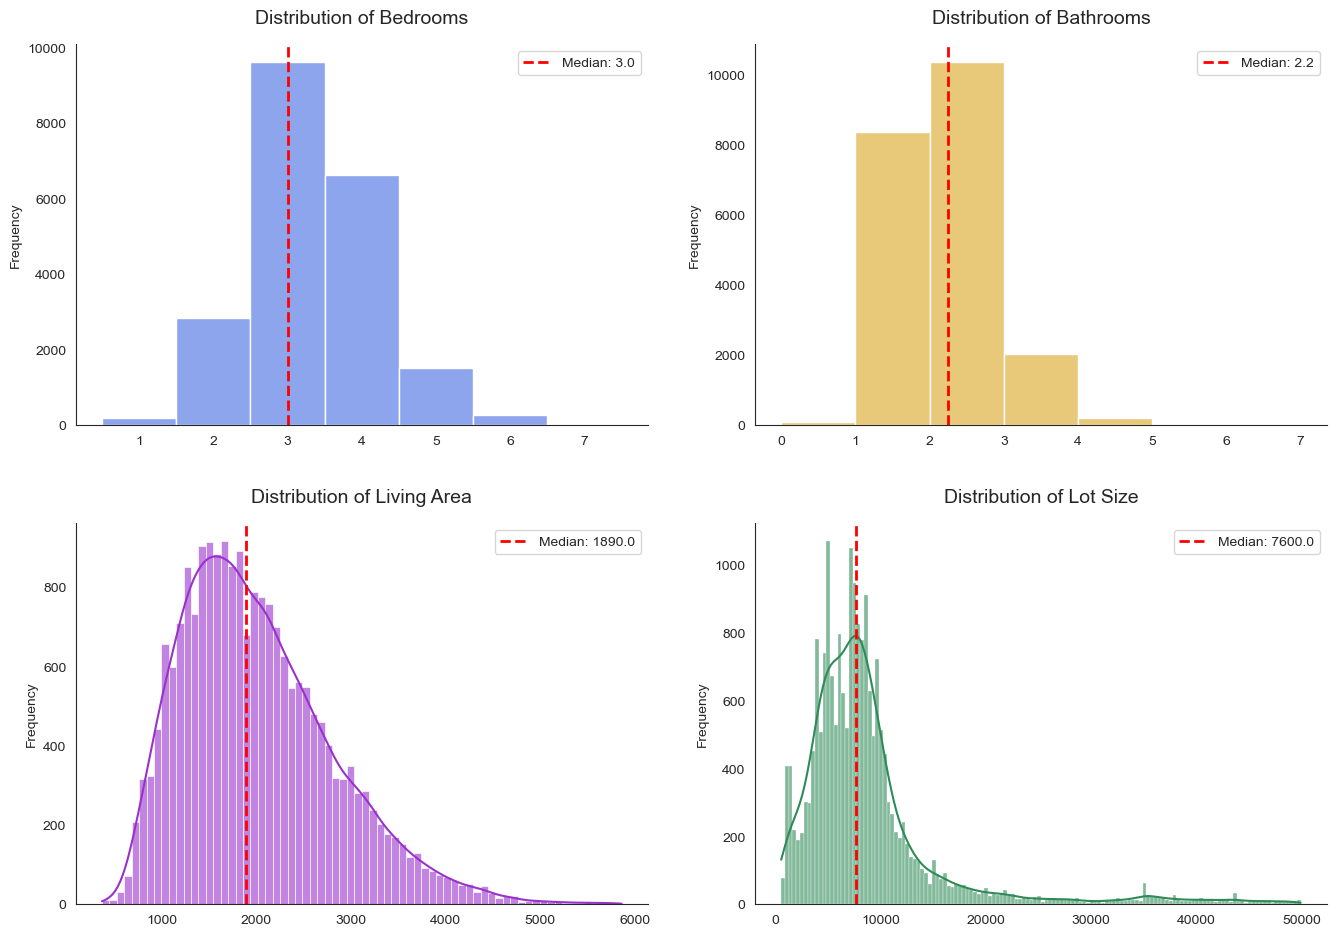

In [298]:
settings = [
    ("bedrooms", "Bedrooms", "royalblue", 10),
    ("bathrooms", "Bathrooms", "goldenrod", 6),
    ("sqft_living", "Living Area", "darkorchid", 6000),
    ("sqft_lot", "Lot Size", "seagreen", 50000),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_style("white")  # Clean white background

for ax, (col, title, color, limit) in zip(axes.flatten(), settings):
    # Filter data for visualization only
    # (prevents outliers from squishing the plot)
    plot_data = (
        df_no_outliers[df_no_outliers[col] <= limit][col]
        if limit
        else df_no_outliers[col]
    )

    # Use discrete=True for counts to center bars on integers
    is_discrete = col in ["bedrooms", "bathrooms"]

    sns.histplot(
        plot_data,
        kde=not is_discrete,
        ax=ax,
        color=color,
        alpha=0.6,
        discrete=is_discrete,
        edgecolor="white",
    )

    # Add median line
    median_val = df_no_outliers[col].median()
    ax.axvline(
        median_val,
        color="red",
        ls="--",
        lw=2,
        label=f"Median: {median_val:.1f}",
    )

    # Professional formatting
    ax.set_title(f"Distribution of {title}", fontsize=14, pad=15)
    ax.set_xlabel(None)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend(frameon=True)
    sns.despine()

plt.tight_layout(pad=3.0)
plt.show()

# Feature Construction
<a id='features'></a>

- Construct features including:

    - Renovation Boolean

    - Living Space to Lot Space Ratio

    - Sale Month

    - Grade Level

    - Condition Level

    - House Age

        - Standard House Age

        - Mean Centered House Age

        - Mean Centered House Age Squared

    - Logged Columns:

        - Price

        - Living Space

        - Living Space Above

        - Living Space Basement (0 kept as 0)

        - Lot Space

        - Lot Space 15
        

In [299]:
# Feature construction for data with and without outliers
dfs = [df_pre_outlier_removal, df_no_outliers]

for d in dfs:
    # Construct house age from date and year built
    d["house_age"] = (d["date"].dt.year - d["yr_built"]).clip(lower=0)
    d["renovated_bool"] = d["yr_renovated"].apply(
        lambda x: 1 if x > 0 else 0
    )

    # Create a few logged variables for visualization and analysis
    log_cols = [
        "price",
        "sqft_living",
        "sqft_above",
        "sqft_basement",
        "sqft_lot",
        "sqft_lot15",
        "sqft_living15",
    ]
    for col in log_cols:
        d[f"log_{col}"] = np.log1p(d[col]).round(4)

    # Living to lot ratio
    d["living_lot_ratio"] = (d["sqft_living"] / d["sqft_lot"]).round(3)

    # Month of sale (that may influence the price)
    d["sale_month"] = d["date"].dt.month

    # Grade/condition groups - lets visualize these in the next step
    # to see if these are meaningful or if we can improve them
    d["grade_level"] = pd.cut(
        d["grade"],
        bins=[0, 6, 9, 13],
        labels=["Low", "Mid", "High"],
    )
    d["condition_level"] = pd.cut(
        d["condition"],
        bins=[0, 2, 3, 5],
        labels=["Poor", "Average", "Good"],
    )

    # Create house age features to capture non-linear relationships
    # with house age
    age_mean = d["house_age"].mean()
    d["house_age_c"] = (d["house_age"] - age_mean).round(2)
    d["house_age_c_sq"] = (d["house_age_c"] ** 2).round(2)

In [300]:
# Columns to drop
cols_to_drop = [
    "id",
    "date",
    "yr_built",
    "yr_renovated",
    "zipcode",
    "lat",
    "long",
]

dfs = [df_pre_outlier_removal, df_no_outliers]

for i, d in enumerate(dfs):
    df_name = "df_pre_outlier_removal" if i == 0 else "df_no_outliers"
    d.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Final shape for {df_name}: {d.shape}")

Final shape for df_pre_outlier_removal: (21613, 29)
Final shape for df_no_outliers: (21096, 29)


# Data Export
<a id='export'></a>

In [301]:
# Save the data frames to the viz step

df_no_outliers.to_csv(
    "../2_Visualization/cleaned_house_sales.csv",
    index=False,
)
df_pre_outlier_removal.to_csv(
    "../2_Visualization/cleaned_house_sales_with_outliers.csv",
    index=False,
)
df_no_outliers.to_csv(
    "../3_Model/cleaned_house_sales.csv",
    index=False,
)
df_pre_outlier_removal.to_csv(
    "../3_Model/cleaned_house_sales_with_outliers.csv",
    index=False,
)

print("Files saved successfully to the Vis and Model folder!")

print("--- Data with no outliers ---")
display(df_no_outliers.head().round(2).T)
print("--- Data with outliers ---")
df_pre_outlier_removal.head().round(2).T

Files saved successfully to the Vis and Model folder!
--- Data with no outliers ---


,0,1,2,3,4
Column,,,,,
price,"221,900.00","538,000.00","180,000.00","604,000.00","510,000.00"
bedrooms,3,3,2,4,3
bathrooms,1.00,2.25,1.00,3.00,2.00
sqft_living,1180,2570,770,1960,1680
sqft_lot,"5,650.00","7,242.00","10,000.00","5,000.00","8,080.00"
floors,1.00,2.00,1.00,1.00,1.00
waterfront,0,0,0,0,0
view,0,0,0,0,0
condition,3,3,3,5,3


--- Data with outliers ---


,0,1,2,3,4
Column,,,,,
price,"221,900.00","538,000.00","180,000.00","604,000.00","510,000.00"
bedrooms,3,3,2,4,3
bathrooms,1.00,2.25,1.00,3.00,2.00
sqft_living,1180,2570,770,1960,1680
sqft_lot,"5,650.00","7,242.00","10,000.00","5,000.00","8,080.00"
floors,1.00,2.00,1.00,1.00,1.00
waterfront,0,0,0,0,0
view,0,0,0,0,0
condition,3,3,3,5,3


# Main Takeaways
<a id='takeaways'></a>

1. Missing values were limited to a small subset of variables and were imputed using context-specific methods to preserve data integrity.
2. Outlier removal was restricted to select variables to avoid excluding valid observations, resulting in the removal of only 2.39% of the data.
3. Additional features were constructed to capture relationships not directly represented in the original dataset.